In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("drug_dataset.csv")

df = df[['review', 'rating']]
df = df.dropna()

df.columns = ['review_text', 'rating']

df


Index(['patient_id', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'review_length'],
      dtype='object')


,review_text,rating
0,"""I have used Restasis for about a year now and...",2.0
1,"""My experience has been somewhat mixed. I have...",7.0
2,"""This is my second Implanon would not recommen...",1.0
3,"""I recommend taking as prescribed, and the bot...",10.0
4,"""I have been on Ampyra for 5 days and have bee...",9.0
...,...,...
110806,"""I had tried many medications to level out my ...",8.0
110807,"""Had partial thyroid removal with benign tumor...",7.0
110808,"""my experience with risperdal started when I f...",8.0
110809,"""My elderly dad was prescribed a low dose of A...",1.0


In [262]:
def find_length(text):
    return len(str(text).split())

df['length'] = df['review_text'].apply(find_length)
df['length'].describe()


count    110811.000000
mean         95.475467
std          38.784704
min          31.000000
25%          63.000000
50%          95.000000
75%         130.000000
max        1894.000000
Name: length, dtype: float64

In [270]:
MAX_LEN = 150
MAX_WORDS = 15000

In [271]:
#Text Clenaing using nlp 

df['review_text'] = df['review_text'].str.lower()

# remove punctuation 

import string 
exclude = string.punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('','',exclude))
df['review_text'] = df['review_text'].apply(remove_punctuation)

# remove spaces 

import re 
def remove_spaces(text):
    return re.sub("\s+"," ",text).strip()
df['review_text'] = df['review_text'].apply(remove_spaces)

df


,review_text,rating,length,label
0,i have used restasis for about a year now and ...,2.0,147,1
1,my experience has been somewhat mixed i have b...,7.0,136,0
2,this is my second implanon would not recommend...,1.0,140,1
3,i recommend taking as prescribed and the bottl...,10.0,104,0
4,i have been on ampyra for 5 days and have been...,9.0,74,0
...,...,...,...,...
110806,i had tried many medications to level out my b...,8.0,141,0
110807,had partial thyroid removal with benign tumor ...,7.0,124,0
110808,my experience with risperdal started when i fi...,8.0,130,0
110809,my elderly dad was prescribed a low dose of at...,1.0,77,1


In [272]:

def rating_to_binary(r):
    if r <= 4:
        return 1 
    elif r >= 7:
        return 0  
    else:
        return np.nan 

df['label'] = df['rating'].apply(rating_to_binary)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print(df['label'].value_counts())



df

label
0    73638
1    27103
Name: count, dtype: int64


,review_text,rating,length,label
0,i have used restasis for about a year now and ...,2.0,147,1
1,my experience has been somewhat mixed i have b...,7.0,136,0
2,this is my second implanon would not recommend...,1.0,140,1
3,i recommend taking as prescribed and the bottl...,10.0,104,0
4,i have been on ampyra for 5 days and have been...,9.0,74,0
...,...,...,...,...
110806,i had tried many medications to level out my b...,8.0,141,0
110807,had partial thyroid removal with benign tumor ...,7.0,124,0
110808,my experience with risperdal started when i fi...,8.0,130,0
110809,my elderly dad was prescribed a low dose of at...,1.0,77,1


In [273]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pickle


X = df['review_text']
y = df['label'] 



tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)

X_padded = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)







In [274]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [275]:
# y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
# y_test = to_categorical(y_test, num_classes=NUM_CLASSES)


with open("drug_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [276]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weight_dict = dict(enumerate(class_weights))



In [277]:
import tensorflow 
from tensorflow import keras 
from tensorflow.keras import  Sequential
from tensorflow.keras.layers import Dense , LSTM , Dropout , Embedding
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# EarlyStopping 
callback = EarlyStopping(
    monitor = 'val_loss',
    restore_best_weights = True,
    patience = 3
)

# Embedding layer 
model.add(Embedding(
    input_dim = MAX_WORDS,
    output_dim = 128
))

# LSTM layer
model.add(LSTM(64 ,return_sequences = False))

#Dropout Layer
model.add(Dropout(0.3))


# Dense layer 
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))




#Compile 
model.compile(loss='binary_crossentropy',optimizer = 'adam' , metrics = ['accuracy'])


history = model.fit(
    X_train, 
    y_train,
    epochs = 100 ,
    callbacks = [callback],
    batch_size = 32,
    validation_split = 0.1,
    class_weight=class_weight_dict
)
history


Epoch 1/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 93s 40ms/step - accuracy: 0.5202 - loss: 0.6894 - val_accuracy: 0.5278 - val_loss: 0.6998
Epoch 2/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 126s 55ms/step - accuracy: 0.8137 - loss: 0.4156 - val_accuracy: 0.8684 - val_loss: 0.3057
Epoch 3/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 123s 54ms/step - accuracy: 0.8844 - loss: 0.2774 - val_accuracy: 0.8690 - val_loss: 0.3221
Epoch 4/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 123s 54ms/step - accuracy: 0.9196 - loss: 0.2030 - val_accuracy: 0.8877 - val_loss: 0.2782
Epoch 5/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 124s 55ms/step - accuracy: 0.9414 - loss: 0.1512 - val_accuracy: 0.8962 - val_loss: 0.2688
Epoch 6/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 124s 55ms/step - accuracy: 0.9595 - loss: 0.1112 - val_accuracy: 0.8999 - val_loss: 0.2926
Epoch 7/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 123s 54ms/step - accuracy: 0.9694 - loss: 0.0849 - val_accuracy: 0.9062 - val_loss: 0.3473
Epoch 8/100
2267/2267 ━━━━━━━━━━━━━━━━━━━━ 125s 55ms/step - acc

In [278]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)
print("Test Loss:", loss)


630/630 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8935 - loss: 0.2786
Test Accuracy: 0.8934934735298157
Test Loss: 0.27863889932632446


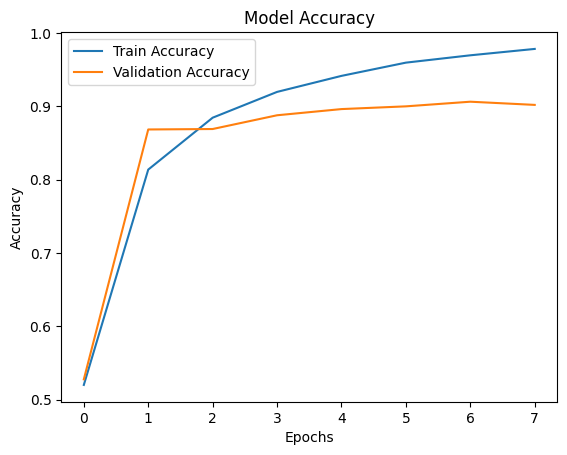

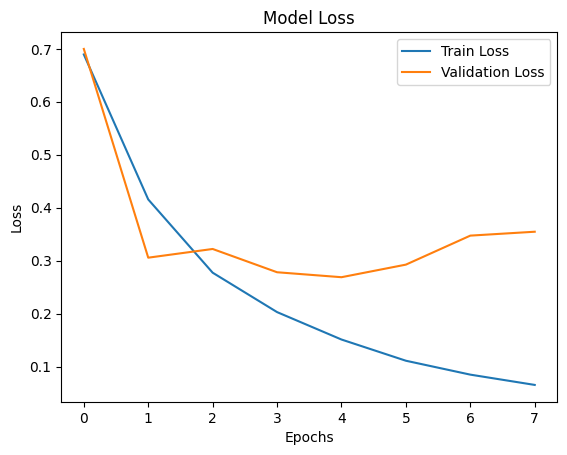

In [279]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


In [280]:
model.save("drug_side_effect_lstm.h5")
